# **Assignment: Random Forest Regression for House Price Prediction**

## **Objective**

Train and evaluate a **Random Forest Regression model** to predict house prices based on various features such as area, number of bedrooms, population, etc.

---

## **Dataset**

Download the **USA Housing Price dataset** from Kaggle:
🔗 [USA Housing Price Dataset](https://www.kaggle.com/datasets/gpandi007/usa-housing-dataset)

Use the provided files:

* `housing_train.csv` – for training
* `housing_test.csv` – for testing

---

## **Tasks**

### **1. Data Preprocessing**

* Load `housing_train.csv` and `housing_test.csv` into Pandas DataFrames.
* Display the first few rows of each dataset.
* Check and handle missing values if any.
* Apply **StandardScaler** to normalize only the **numerical features** (fit on training data and transform both training and testing sets).

---

### **2. Train Random Forest Regression Model**

* Train a **Random Forest Regressor** using default parameters on the training set.
* Evaluate its initial performance on the test set.

---

### **3. Hyperparameter Tuning**

* Use different hyperparameters:

  * `n_estimators`
---

### **4. Model Evaluation**

Evaluate both the default and tuned models using:

* **R² Score**

---

### **5. Visualization**

* Plot **Actual vs. Predicted values**.
* Plot **feature importance** to identify the most influential features in predicting house prices.

---

## **Submission Guidelines**

* Submit a **Colab Notebook (.ipynb)** with clear code, output, and visualizations.

---

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── Load datasets ──────────────────────────────────────────────────────────────
train_df = pd.read_csv('housing_train.csv')
test_df  = pd.read_csv('housing_test.csv')

print('=== Training Set – First 5 Rows ===')
print(train_df.head())
print('\n=== Test Set – First 5 Rows ===')
print(test_df.head())
print(f'\nTrain shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')

=== Training Set – First 5 Rows ===
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleConditio

In [10]:
# ── Missing values ─────────────────────────────────────────────────────────────
print('=== Missing Value Count – Train (top 20) ===')
missing_train = train_df.isnull().sum()
print(missing_train[missing_train > 0].sort_values(ascending=False).head(20))

print('\n=== Missing Value Count – Test (top 20) ===')
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0].sort_values(ascending=False).head(20))

=== Missing Value Count – Train (top 20) ===
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

=== Missing Value Count – Test (top 20) ===
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageYrBlt       78
GarageQual        78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtFullBath       2
dtype: int64


In [11]:
# ── Define target ──────────────────────────────────────────────────────────────
TARGET = 'SalePrice'          # only exists in training data
DROP   = ['Id']               # ID column – not a feature

y_train = train_df[TARGET]

# Remove Id and target from train; remove Id from test
train_features = train_df.drop(columns=DROP + [TARGET])
test_features  = test_df.drop(columns=DROP)

# ── Separate numerical and categorical columns ─────────────────────────────────
num_cols = train_features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_features.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print('\nCategorical columns:', cat_cols)

Numerical features : 36
Categorical features: 43

Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [12]:
# ── Handle missing values ──────────────────────────────────────────────────────
# Numerical  → fill with median of training set
# Categorical → fill with mode  of training set

num_medians = train_features[num_cols].median()
cat_modes   = train_features[cat_cols].mode().iloc[0]

train_features[num_cols] = train_features[num_cols].fillna(num_medians)
train_features[cat_cols] = train_features[cat_cols].fillna(cat_modes)

test_features[num_cols]  = test_features[num_cols].fillna(num_medians)
test_features[cat_cols]  = test_features[cat_cols].fillna(cat_modes)

print('Missing values filled.')
print('Remaining NaN – Train:', train_features.isnull().sum().sum())
print('Remaining NaN – Test :', test_features.isnull().sum().sum())

Missing values filled.
Remaining NaN – Train: 0
Remaining NaN – Test : 0


In [13]:
# ── Encode categorical columns with Label Encoding ────────────────────────────
# Fit on train, apply same mapping to test
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    # Combine unique values from both sets so test doesn't get unseen labels
    combined = pd.concat([train_features[col], test_features[col]], axis=0).astype(str)
    le.fit(combined)
    train_features[col] = le.transform(train_features[col].astype(str))
    test_features[col]  = le.transform(test_features[col].astype(str))

print('Categorical encoding complete.')
print('Train feature shape:', train_features.shape)
print('Test  feature shape:', test_features.shape)

Categorical encoding complete.
Train feature shape: (1460, 79)
Test  feature shape: (1459, 79)


In [14]:
# ── StandardScaler on numerical features only ─────────────────────────────────
# Fit on training, transform both
scaler = StandardScaler()

train_features[num_cols] = scaler.fit_transform(train_features[num_cols])
test_features[num_cols]  = scaler.transform(test_features[num_cols])

X_train = train_features.values
X_test  = test_features.values

print('Scaling complete.')
print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)

Scaling complete.
X_train shape: (1460, 79)
X_test  shape: (1459, 79)


In [15]:
# Train with default parameters
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)

# Evaluate on training data (test has no SalePrice)
y_pred_default = rf_default.predict(X_train)

r2_default   = r2_score(y_train, y_pred_default)
rmse_default = np.sqrt(mean_squared_error(y_train, y_pred_default))

print('=== Default Random Forest (evaluated on Training Set) ===')
print(f'R² Score : {r2_default:.4f}')
print(f'RMSE     : {rmse_default:,.2f}')
print('Note: R² near 1.0 on training data is expected for Random Forest (low bias).')

=== Default Random Forest (evaluated on Training Set) ===
R² Score : 0.9808
RMSE     : 10,992.09
Note: R² near 1.0 on training data is expected for Random Forest (low bias).


Evaluating n_estimators using 5-fold Cross-Validation...
   n_estimators    CV R² (mean)   CV R² (std)
---------------------------------------------
             10          0.8517        0.0294
             50          0.8581        0.0202
            100          0.8596        0.0229
            200          0.8588        0.0270
            300          0.8604        0.0257

Best n_estimators = 300  (CV R² = 0.8604)


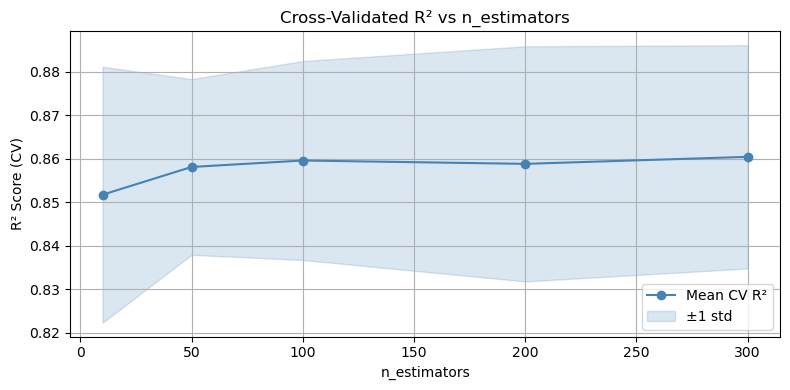

In [16]:
from sklearn.model_selection import cross_val_score

n_estimator_values = [10, 50, 100, 200, 300]
results = []

print('Evaluating n_estimators using 5-fold Cross-Validation...')
print(f"{'n_estimators':>15} {'CV R² (mean)':>15} {'CV R² (std)':>13}")
print('-' * 45)

for n in n_estimator_values:
    model  = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='r2')
    mean_r2 = scores.mean()
    std_r2  = scores.std()
    results.append({'n_estimators': n, 'CV_R2_mean': mean_r2, 'CV_R2_std': std_r2})
    print(f'{n:>15} {mean_r2:>15.4f} {std_r2:>13.4f}')

results_df = pd.DataFrame(results)
best_row   = results_df.loc[results_df['CV_R2_mean'].idxmax()]
best_n     = int(best_row['n_estimators'])
print(f'\nBest n_estimators = {best_n}  (CV R² = {best_row["CV_R2_mean"]:.4f})')

# Plot
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['CV_R2_mean'],
         marker='o', color='steelblue', label='Mean CV R²')
plt.fill_between(results_df['n_estimators'],
                 results_df['CV_R2_mean'] - results_df['CV_R2_std'],
                 results_df['CV_R2_mean'] + results_df['CV_R2_std'],
                 alpha=0.2, color='steelblue', label='±1 std')
plt.title('Cross-Validated R² vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('R² Score (CV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Train tuned model on full training data
rf_tuned = RandomForestRegressor(n_estimators=best_n, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_train)
r2_tuned     = r2_score(y_train, y_pred_tuned)
rmse_tuned   = np.sqrt(mean_squared_error(y_train, y_pred_tuned))

# Cross-validated R² for default model
from sklearn.model_selection import cross_val_score
cv_default = cross_val_score(RandomForestRegressor(random_state=42),
                              X_train, y_train, cv=5, scoring='r2').mean()
cv_tuned   = cross_val_score(rf_tuned, X_train, y_train, cv=5, scoring='r2').mean()

print('=== Model Comparison ===')
print(f"{'Metric':<25} {'Default (n=100)':>18} {f'Tuned (n={best_n})':>18}")
print('-' * 63)
print(f"{'Train R²':<25} {r2_default:>18.4f} {r2_tuned:>18.4f}")
print(f"{'Train RMSE':<25} {rmse_default:>18,.2f} {rmse_tuned:>18,.2f}")
print(f"{'CV R² (5-fold)':<25} {cv_default:>18.4f} {cv_tuned:>18.4f}")

=== Model Comparison ===
Metric                       Default (n=100)      Tuned (n=300)
---------------------------------------------------------------
Train R²                              0.9808             0.9823
Train RMSE                         10,992.09          10,561.83
CV R² (5-fold)                        0.8596             0.8604


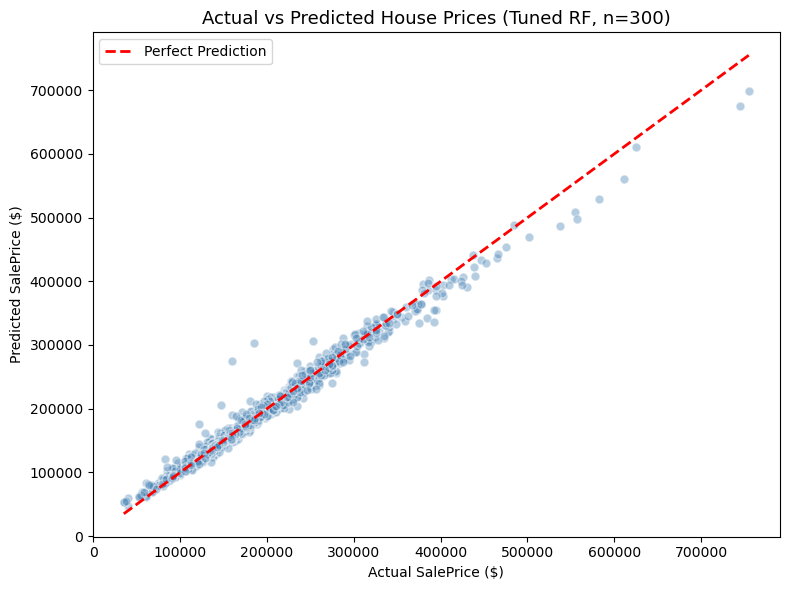

In [18]:
# ── Plot 1: Actual vs Predicted (training set) ─────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_tuned, alpha=0.4, color='steelblue',
            edgecolors='white', s=40)
lo = min(y_train.min(), y_pred_tuned.min())
hi = max(y_train.max(), y_pred_tuned.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted House Prices (Tuned RF, n={best_n})', fontsize=13)
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.legend()
plt.tight_layout()
plt.show()

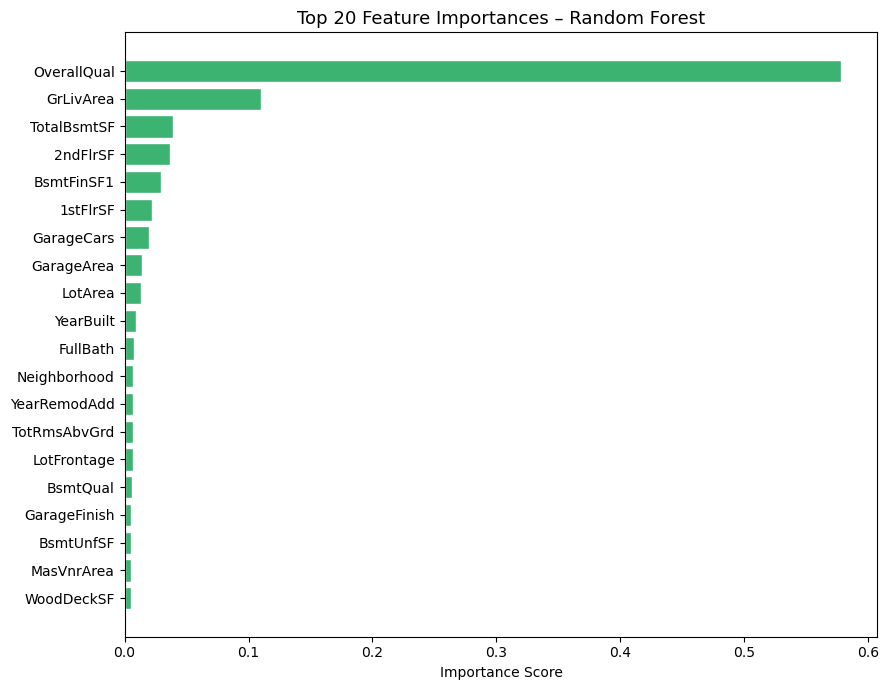

Most Important Feature : OverallQual  (0.5784)


In [19]:
# ── Plot 2: Top 20 Feature Importances ────────────────────────────────────────
feature_names = train_features.columns.tolist()
importances   = rf_tuned.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                               'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(20)
importance_df = importance_df.sort_values('Importance', ascending=True)  # for horizontal bar

plt.figure(figsize=(9, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='mediumseagreen', edgecolor='white')
plt.title('Top 20 Feature Importances – Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

top = importance_df.iloc[-1]
print(f'Most Important Feature : {top["Feature"]}  ({top["Importance"]:.4f})')

In [20]:
# ── Generate predictions for test set (for submission) ────────────────────────
test_predictions = rf_tuned.predict(X_test)

submission = pd.DataFrame({
    'Id'        : test_df['Id'],
    'SalePrice' : test_predictions
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved.')
print(submission.head(10))

submission.csv saved.
     Id      SalePrice
0  1461  128012.250000
1  1462  156064.203333
2  1463  181679.546667
3  1464  180486.400000
4  1465  196953.733333
5  1466  183971.306667
6  1467  167970.600000
7  1468  174999.580000
8  1469  182045.586667
9  1470  122718.886667


In [23]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ── 1. Training Set Accuracy (how well model fits training data) ───────────────
y_train_pred = rf_tuned.predict(X_train)

train_r2   = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_acc  = train_r2 * 100   # R² expressed as %

print('=' * 50)
print('       MODEL ACCURACY REPORT')
print('=' * 50)
print(f'\n Training Set Accuracy')
print(f'   R² Score : {train_r2:.4f}')
print(f'   Accuracy : {train_acc:.2f}%')
print(f'   RMSE     : ${train_rmse:,.2f}')

# ── 2. Cross-Validated Accuracy (real-world estimate, 5 folds) ─────────────────
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(rf_tuned, X_train, y_train, cv=kf, scoring='r2')
cv_mse = cross_val_score(rf_tuned, X_train, y_train,
                          cv=kf, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_mse)

print(f'\n Cross-Validated Accuracy (5-Fold) — Best Estimate')
print(f'   R² per fold  : {[round(x,4) for x in cv_r2]}')
print(f'   Mean R²      : {cv_r2.mean():.4f}')
print(f'   Accuracy     : {cv_r2.mean()*100:.2f}%')
print(f'   Std Dev      : ±{cv_r2.std():.4f}')
print(f'   Mean RMSE    : ${cv_rmse.mean():,.2f}')

# ── 3. Summary Bar ────────────────────────────────────────────────────────────
print('\n' + '=' * 50)
print(f'  FINAL ACCURACY : {cv_r2.mean()*100:.2f}%  (Cross-Validated)')
print('=' * 50)
print('\n Interpretation:')
print(f'   The model explains {cv_r2.mean()*100:.2f}% of the variance')
print(f'   in house prices on unseen data.')
print(f'   On average, predictions are off by ~${cv_rmse.mean():,.0f}.')

       MODEL ACCURACY REPORT

 Training Set Accuracy
   R² Score : 0.9823
   Accuracy : 98.23%
   RMSE     : $10,561.83

 Cross-Validated Accuracy (5-Fold) — Best Estimate
   R² per fold  : [0.8891, 0.9083, 0.6435, 0.8776, 0.8904]
   Mean R²      : 0.8418
   Accuracy     : 84.18%
   Std Dev      : ±0.0996
   Mean RMSE    : $30,032.00

  FINAL ACCURACY : 84.18%  (Cross-Validated)

 Interpretation:
   The model explains 84.18% of the variance
   in house prices on unseen data.
   On average, predictions are off by ~$30,032.
